/tmp/ipykernel_5657/1750052244.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vel_df["mean_velocity_30d"] = (
/tmp/ipykernel_5657/1750052244.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vel_df["time_gap_days"] = (


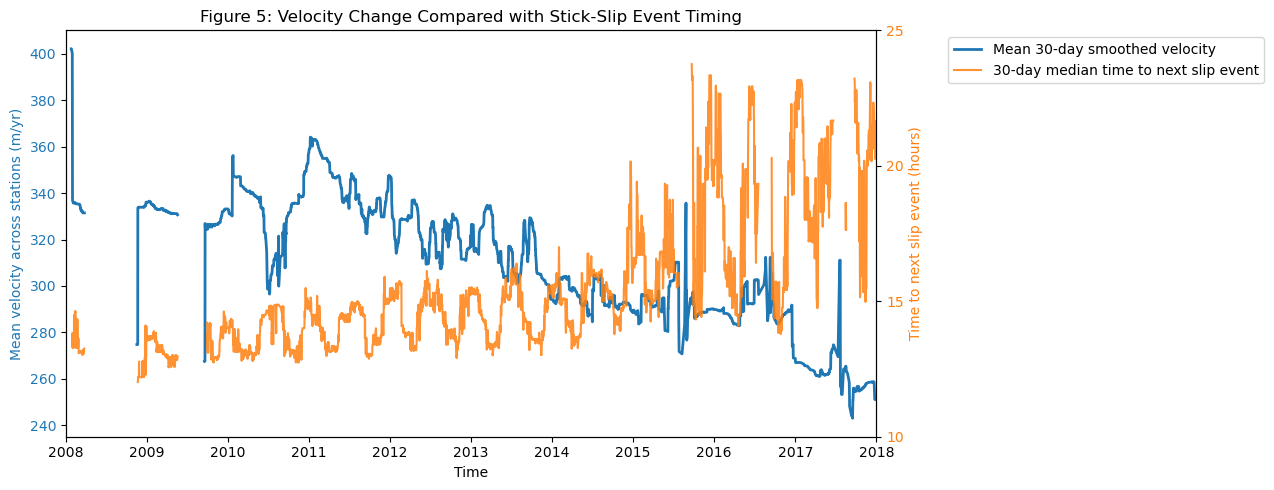

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


# Load velocity/event dataset

vel_df = pd.read_csv(
    "../Data/whillans_events_with_velocity(in).csv",
    parse_dates=["start_time"]
)

vel_df = vel_df.sort_values("start_time").reset_index(drop=True)


# Mean 30-day smoothed velocity across stations


v30d_cols = [c for c in vel_df.columns if c.startswith("v30d_")]

vel_df["mean_velocity_30d"] = (
    vel_df[v30d_cols]
    .mean(axis=1, skipna=True)
)


# Break velocity line across large gaps


vel_df["time_gap_days"] = (
    vel_df["start_time"]
    .diff()
    .dt.days
)

vel_df.loc[
    vel_df["time_gap_days"] > 45,
    "mean_velocity_30d"
] = pd.NA

# Create event timing dataframe

event_df = vel_df[
    ["start_time", "time_since_hrs"]
].copy()

event_df = event_df.sort_values(
    "start_time"
).reset_index(drop=True)


# Convert "time since previous event" into "time to next event"


event_df["time_to_next_ev_hr"] = (
    event_df["time_since_hrs"]
    .shift(-1)
)

# Remove final row with no next event
event_df = event_df.dropna(
    subset=["time_to_next_ev_hr"]
)


# filter long inactive periods


event_df = event_df[
    event_df["time_to_next_ev_hr"] < 36
].copy()


# Calculate 30-day rolling median


event_df = event_df.set_index(
    "start_time"
).sort_index()

event_df["time_to_next_30d"] = (
    event_df["time_to_next_ev_hr"]
    .rolling("30D", min_periods=10)
    .median()
)

event_df = event_df.reset_index()


# Plot


fig, ax1 = plt.subplots(figsize=(13, 5))


# Velocity line


line1 = ax1.plot(
    vel_df["start_time"],
    vel_df["mean_velocity_30d"],
    label="Mean 30-day smoothed velocity",
    linewidth=2
)

ax1.set_xlabel("Time")

ax1.set_ylabel(
    "Mean velocity across stations (m/yr)",
    color="tab:blue"
)

ax1.tick_params(
    axis="y",
    labelcolor="tab:blue"
)

# Event timing line


ax2 = ax1.twinx()

line2 = ax2.plot(
    event_df["start_time"],
    event_df["time_to_next_30d"],
    label="30-day median time to next slip event",
    color="tab:orange",
    linewidth=1.5,
    alpha=0.85
)

ax2.set_ylabel(
    "Time to next slip event (hours)",
    color="tab:orange"
)

ax2.tick_params(
    axis="y",
    labelcolor="tab:orange"
)


# Manual right-axis scaling


ax2.set_ylim(10, 25)

ax2.set_yticks([10, 15, 20, 25])


# Title


ax1.set_title(
    "Figure 5: Velocity Change Compared with Stick-Slip Event Timing"
)

# Legend


lines = line1 + line2

labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left",
    bbox_to_anchor=(1.08, 1),
    frameon=True
)

# X-axis limits


ax1.set_xlim(
    pd.Timestamp("2008-01-01"),
    pd.Timestamp("2018-01-01")
)

fig.tight_layout()

plt.show()

# Save 


fig.savefig(
    "../Figures/figure5_velocity_event_timing.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../Figures/figure5_velocity_event_timing.png",
    dpi=200,
    bbox_inches="tight"
)

### Figure 5 Interpertation: 

Figure 5 compares changes in mean ice velocity with the timing between stick-slip events from 2008 to 2018. The blue line shows the mean 30-day smoothed velocity across all stations, while the orange line shows the 30-day median time to the next slip event. Overall, there is a noticeable inverse relationship between velocity and event timing. When the ice velocity is relatively high (around 2010–2012), the time between slip events tends to be shorter, indicating more frequent stick-slip behavior. As velocity gradually decreases after about 2013, the time between events generally increases, meaning slip events become less frequent. This pattern suggests that faster-moving ice is associated with more frequent slip events, while slower-moving ice corresponds to longer intervals between events. The smoothed lines make this relationship easier to see by reducing short-term variability. Although the relationship is not perfectly consistent at all times, the overall trend supports the idea that changes in ice velocity are linked to changes in stick-slip event frequency across the Whillans Ice Plain.